# Assignment 4

**Group 18:**
- Isaac Adoboe &mdash; ieadoboe@mun.ca
- Blessing Ijeoma Benjamin-Igwe &mdash; bbenjaminigw@mun.ca
- Promee Shankar Kundu &mdash; pskundu@mun.ca

## Imports

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

## Configuration & Helper Functions

In [43]:
mpl_config = {
    "figure.figsize": (12, 6),
    "savefig.dpi": 300,
    "figure.dpi": 150,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.serif": ["Computer Modern"],
    "text.usetex": True,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "axes.linewidth": 0.8,
    "savefig.bbox": "tight",
}
mpl.rcParams.update(mpl_config)

FEATURE_NAMES = [
    "ctx-lh-inferiorparietal",
    "ctx-lh-inferiortemporal",
    "ctx-lh-isthmuscingulate",
    "ctx-lh-middletemporal",
    "ctx-lh-posteriorcingulate",
    "ctx-lh-precuneus",
    "ctx-rh-isthmuscingulate",
    "ctx-rh-posteriorcingulate",
    "ctx-rh-inferiorparietal",
    "ctx-rh-middletemporal",
    "ctx-rh-precuneus",
    "ctx-rh-inferiortemporal",
    "ctx-lh-entorhinal",
    "ctx-lh-supramarginal",
]

performance_results = {}

In [44]:
def load_data(data_dir="."):
    train_sMCI = pd.read_csv(
        os.path.join(data_dir, "train.fdg_pet.sMCI.csv"), header=None,
        names=FEATURE_NAMES)
    train_pMCI = pd.read_csv(
        os.path.join(data_dir, "train.fdg_pet.pMCI.csv"), header=None,
        names=FEATURE_NAMES)
    test_sMCI = pd.read_csv(
        os.path.join(data_dir, "test.fdg_pet.sMCI.csv"), header=None,
        names=FEATURE_NAMES)
    test_pMCI = pd.read_csv(
        os.path.join(data_dir, "test.fdg_pet.pMCI.csv"), header=None,
        names=FEATURE_NAMES)

    # Combine into train / test with labels (sMCI=0, pMCI=1)
    X_train = pd.concat([train_sMCI, train_pMCI], ignore_index=True)
    y_train = np.array([0] * len(train_sMCI) + [1] * len(train_pMCI))

    X_test = pd.concat([test_sMCI, test_pMCI], ignore_index=True)
    y_test = np.array([0] * len(test_sMCI) + [1] * len(test_pMCI))

    print(f"Training set: {len(train_sMCI)} sMCI + {len(train_pMCI)} pMCI"
          f" = {len(X_train)} total")
    print(f"Test set:     {len(test_sMCI)} sMCI + {len(test_pMCI)} pMCI"
          f" = {len(X_test)} total")
    print(f"Features:     {X_train.shape[1]}")

    return X_train, y_train, X_test, y_test


def calc_metrics(y_true, y_pred):
    """Calculate all required performance metrics.
    sMCI=0 (negative), pMCI=1 (positive)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn)  # recall for positive class (pMCI)
    specificity = tn / (tn + fp)  # recall for negative class (sMCI)
    precision = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    return {
        "Accuracy": acc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "Recall": rec,
        "Balanced Accuracy": bal_acc,
    }


def print_metrics(metrics, title=""):
    if title:
        print(f"\n{title}")
    for k, v in metrics.items():
        print(f"  {k:20s}: {v:.4f}")

## Load Data

In [45]:
X_train, y_train, X_test, y_test = load_data()

Training set: 202 sMCI + 202 pMCI = 404 total
Test set:     361 sMCI + 194 pMCI = 555 total
Features:     14


## Question 1 &mdash; Single Decision Tree

In [46]:
print("=" * 70)
print("QUESTION 1: Single Decision Tree Classification")
print("=" * 70)

# Grid search over feature testing criterion
param_grid = {"criterion": ["gini", "entropy", "log_loss"]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    dt,
    param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

print("\nRunning grid search for feature testing criterion...")
print(f"  Criteria: {param_grid['criterion']}")
print("  Cross-validation: 5-fold stratified")

grid_search.fit(X_train, y_train)

best_criterion = grid_search.best_params_["criterion"]
best_cv_score = grid_search.best_score_

print(f"\nBest criterion: {best_criterion}")
print(f"Best CV Balanced Accuracy: {best_cv_score:.4f}")

# Display CV results for all criteria
cv_results = grid_search.cv_results_
print("\nCV Results for all criteria:")
for i, criterion in enumerate(cv_results["param_criterion"]):
    mean_score = cv_results["mean_test_score"][i]
    std_score = cv_results["std_test_score"][i]
    mean_train = cv_results["mean_train_score"][i]
    print(f"  {criterion:10s}: CV={mean_score:.4f} +/- {std_score:.4f}"
          f"  Train={mean_train:.4f}")

QUESTION 1: Single Decision Tree Classification

Running grid search for feature testing criterion...
  Criteria: ['gini', 'entropy', 'log_loss']
  Cross-validation: 5-fold stratified
Fitting 5 folds for each of 3 candidates, totalling 15 fits



Best criterion: entropy
Best CV Balanced Accuracy: 0.5763

CV Results for all criteria:
  gini      : CV=0.5737 +/- 0.0261  Train=1.0000
  entropy   : CV=0.5763 +/- 0.0277  Train=1.0000
  log_loss  : CV=0.5763 +/- 0.0277  Train=1.0000


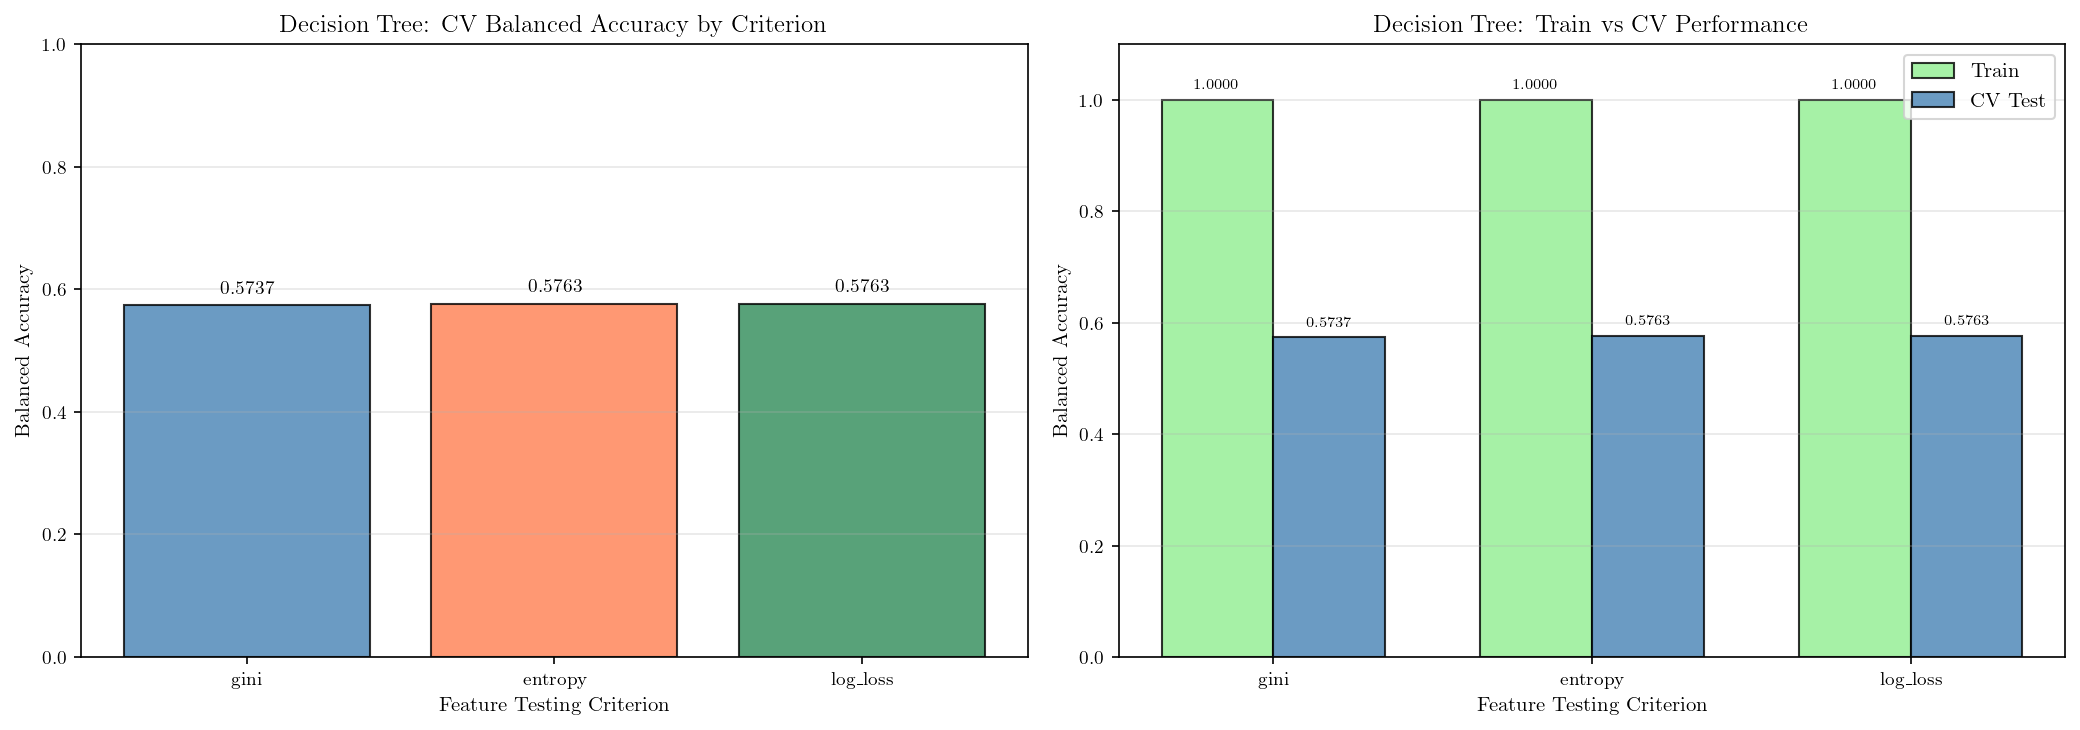

In [47]:
# Plot CV performance for each criterion
criteria = list(cv_results["param_criterion"])
mean_test_scores = cv_results["mean_test_score"]
std_test_scores = cv_results["std_test_score"]
mean_train_scores = cv_results["mean_train_score"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of CV scores
x_pos = np.arange(len(criteria))
colors = ["steelblue", "coral", "seagreen"]
bars = axes[0].bar(x_pos, mean_test_scores,
                   color=colors, alpha=0.8, edgecolor="black",
                   capsize=5)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(criteria)
axes[0].set_xlabel("Feature Testing Criterion")
axes[0].set_ylabel("Balanced Accuracy")
axes[0].set_title("Decision Tree: CV Balanced Accuracy by Criterion")
axes[0].set_ylim([0, 1.0])
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, mean_test_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f"{val:.4f}", ha="center", fontsize=9)

# Right: Train vs CV comparison
width = 0.35
bars_train = axes[1].bar(x_pos - width / 2, mean_train_scores, width,
                         label="Train", color="lightgreen",
                         edgecolor="black", alpha=0.8)
bars_test = axes[1].bar(x_pos + width / 2, mean_test_scores, width,
                        label="CV Test", color="steelblue",
                        edgecolor="black", alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(criteria)
axes[1].set_xlabel("Feature Testing Criterion")
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_title("Decision Tree: Train vs CV Performance")
axes[1].set_ylim([0, 1.1])
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(bars_train, mean_train_scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f"{val:.4f}", ha="center", fontsize=7)
for bar, val in zip(bars_test, mean_test_scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f"{val:.4f}", ha="center", fontsize=7)

plt.tight_layout()
os.makedirs("q1", exist_ok=True)
plt.savefig("q1/q1_dt_criterion_tuning.pdf")
plt.show()

In [48]:
# Retrain on full training set with best criterion
dt_final = DecisionTreeClassifier(
    criterion=best_criterion, random_state=42)
dt_final.fit(X_train, y_train)

# Evaluate on test set
y_pred = dt_final.predict(X_test)
metrics_dt = calc_metrics(y_test, y_pred)
print_metrics(metrics_dt, "Decision Tree - Test Set Performance:")

performance_results["Decision Tree"] = metrics_dt


Decision Tree - Test Set Performance:
  Accuracy            : 0.5856
  Sensitivity         : 0.6134
  Specificity         : 0.5706
  Precision           : 0.4343
  Recall              : 0.6134
  Balanced Accuracy   : 0.5920


## Question 2 &mdash; Decision Tree Visualization & Feature Importance

QUESTION 2: Decision Tree Visualization & Feature Importance


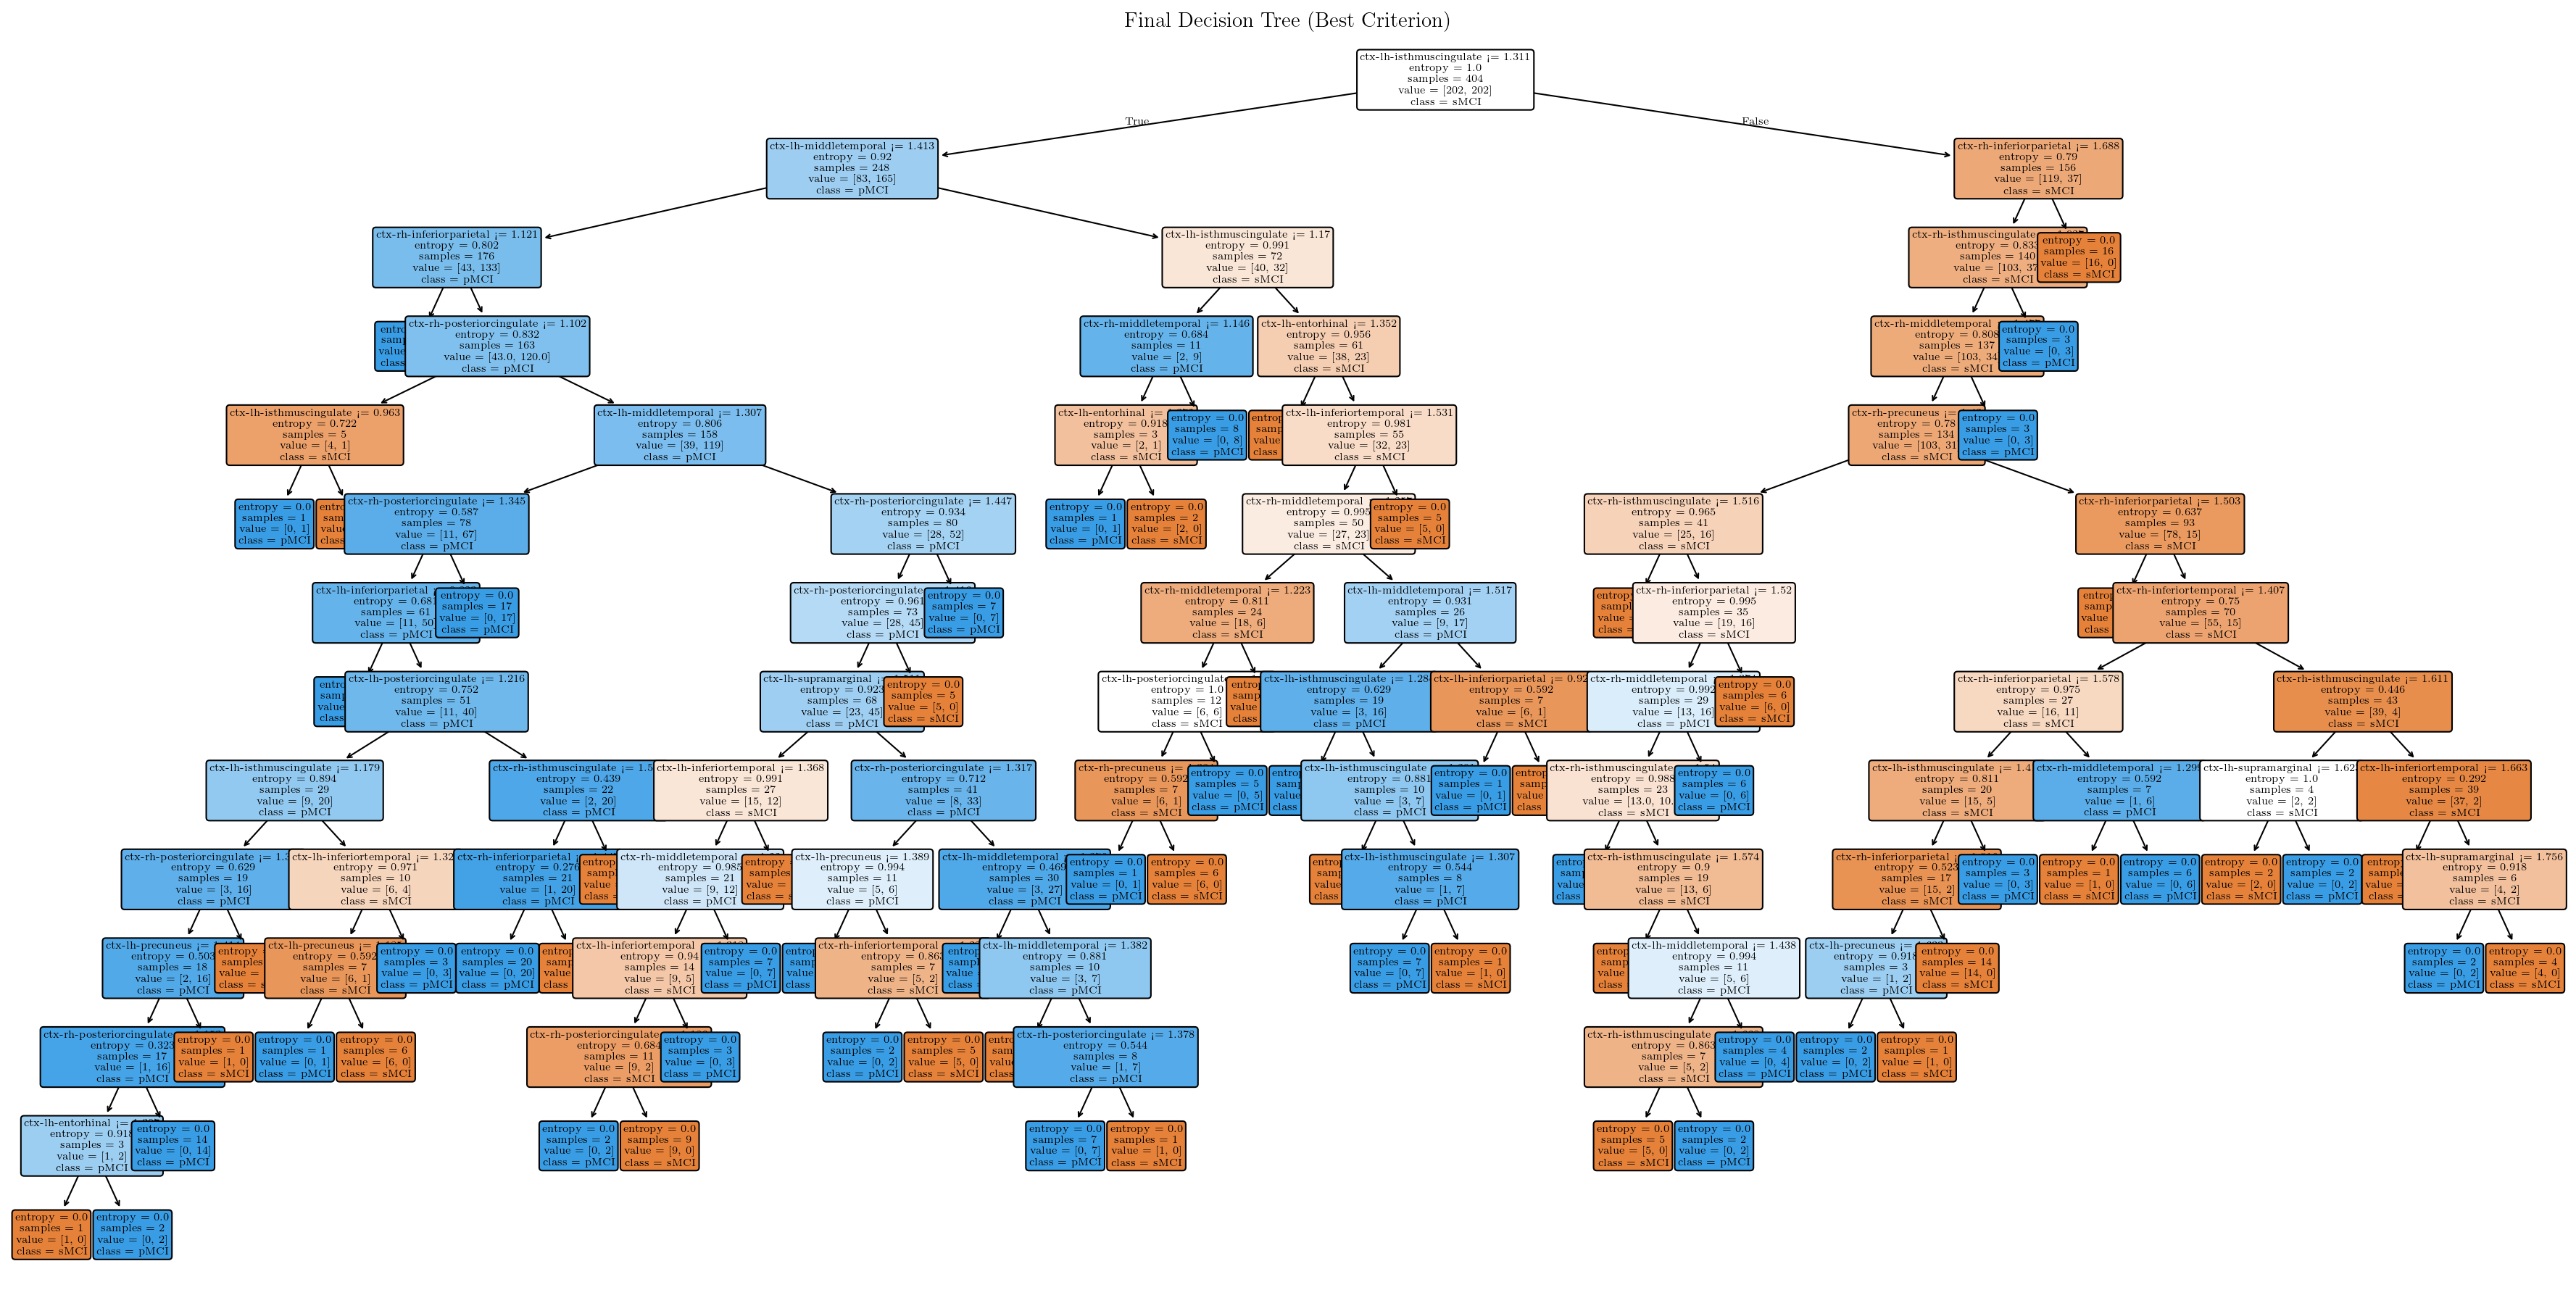

In [49]:
print("=" * 70)
print("QUESTION 2: Decision Tree Visualization & Feature Importance")
print("=" * 70)

# Plot the decision tree
fig, ax = plt.subplots(1, 1, figsize=(24, 12))
plot_tree(
    dt_final,
    feature_names=FEATURE_NAMES,
    class_names=["sMCI", "pMCI"],
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax,
)
ax.set_title("Final Decision Tree (Best Criterion)", fontsize=14)
plt.tight_layout()
os.makedirs("q2", exist_ok=True)
plt.savefig("q2/q2_decision_tree_plot.pdf")
plt.show()

Feature Importances (sorted):
   1. ctx-lh-isthmuscingulate       : 0.2112
   2. ctx-lh-middletemporal         : 0.1117
   3. ctx-rh-inferiorparietal       : 0.1061
   4. ctx-rh-posteriorcingulate     : 0.1054
   5. ctx-rh-middletemporal         : 0.1046
   6. ctx-rh-isthmuscingulate       : 0.0895
   7. ctx-lh-inferiortemporal       : 0.0676
   8. ctx-lh-supramarginal          : 0.0404
   9. ctx-lh-precuneus              : 0.0380
  10. ctx-rh-inferiortemporal       : 0.0321
  11. ctx-lh-posteriorcingulate     : 0.0263
  12. ctx-lh-entorhinal             : 0.0245
  13. ctx-rh-precuneus              : 0.0244
  14. ctx-lh-inferiorparietal       : 0.0181


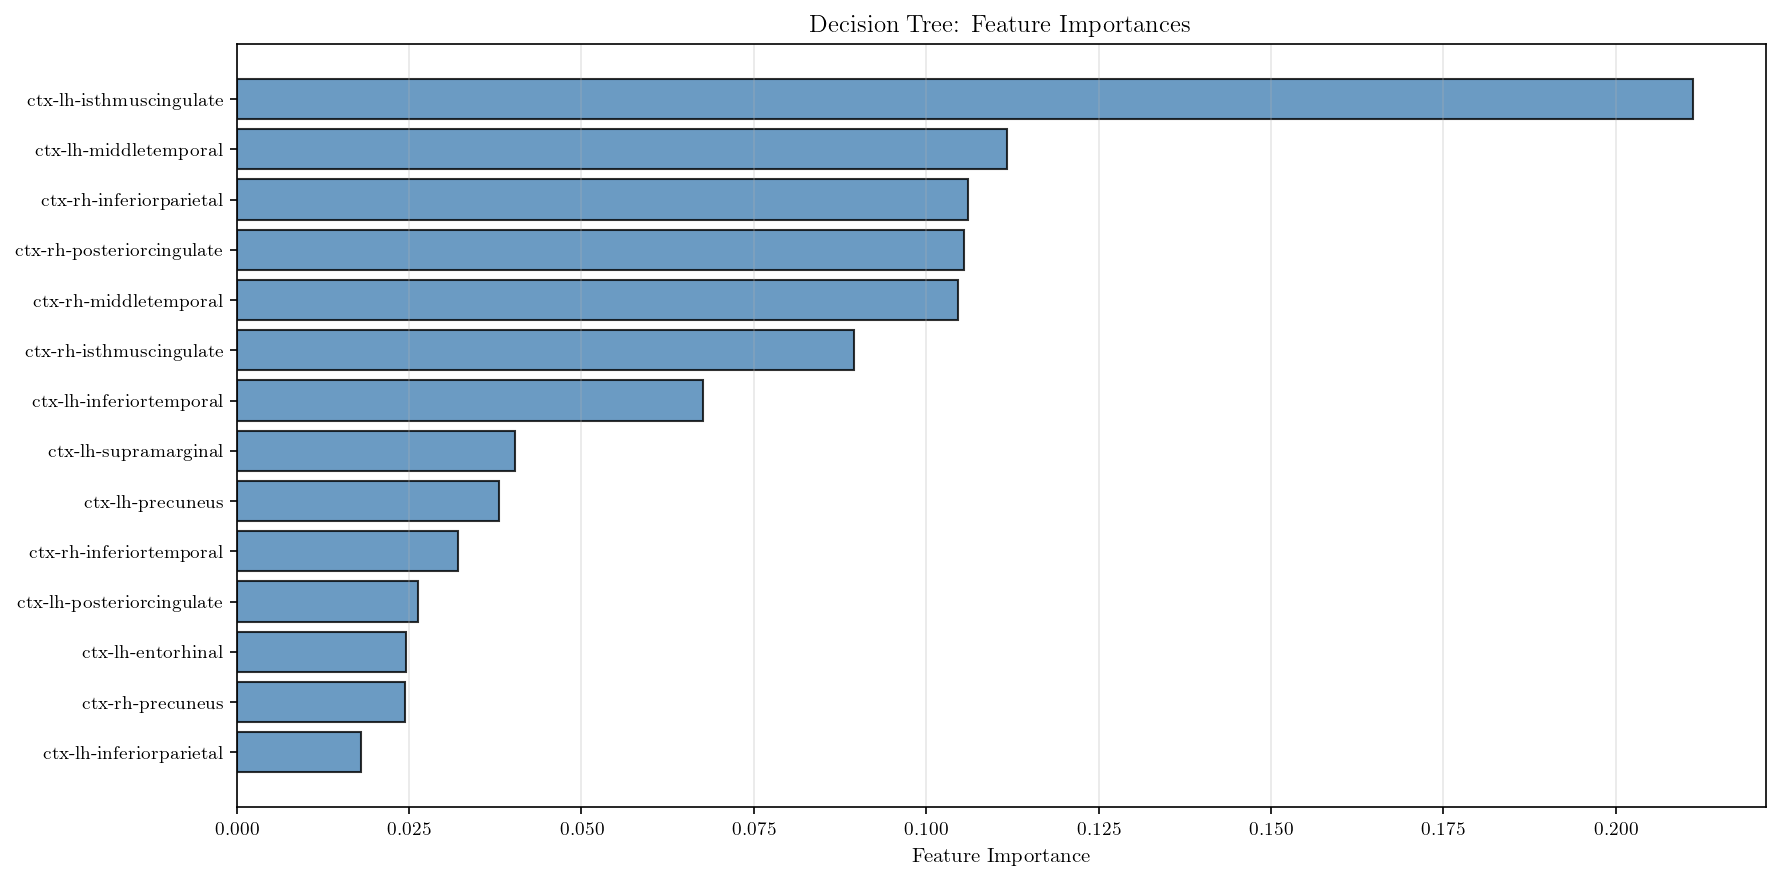

In [50]:
# Feature importance
importances = dt_final.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("Feature Importances (sorted):")
for rank, idx in enumerate(sorted_idx, 1):
    print(f"  {rank:2d}. {FEATURE_NAMES[idx]:30s}: {importances[idx]:.4f}")

# Plot feature importances
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.barh(range(len(FEATURE_NAMES)),
        importances[sorted_idx[::-1]],
        color="steelblue", edgecolor="black", alpha=0.8)
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_yticklabels([FEATURE_NAMES[i] for i in sorted_idx[::-1]])
ax.set_xlabel("Feature Importance")
ax.set_title("Decision Tree: Feature Importances")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("q2/q2_feature_importances.pdf")
plt.show()

In [51]:
# Tree structure summary
n_nodes = dt_final.tree_.node_count
max_depth = dt_final.get_depth()
n_leaves = dt_final.get_n_leaves()
print(f"Tree Structure:")
print(f"  Number of nodes:  {n_nodes}")
print(f"  Maximum depth:    {max_depth}")
print(f"  Number of leaves: {n_leaves}")

Tree Structure:
  Number of nodes:  135
  Maximum depth:    13
  Number of leaves: 68


## Question 3 &mdash; Random Forest

In [52]:
print("=" * 70)
print("QUESTION 3: Random Forest Classification")
print("=" * 70)

# Grid search over feature testing criterion
param_grid = {"criterion": ["gini", "entropy", "log_loss"]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

print("\nRunning grid search for feature testing criterion...")
print(f"  Criteria: {param_grid['criterion']}")
print("  n_estimators: 100")
print("  Cross-validation: 5-fold stratified")

grid_search.fit(X_train, y_train)

best_rf_criterion = grid_search.best_params_["criterion"]
best_cv_score = grid_search.best_score_

print(f"\nBest criterion: {best_rf_criterion}")
print(f"Best CV Balanced Accuracy: {best_cv_score:.4f}")

# Display CV results for all criteria
cv_results = grid_search.cv_results_
print("\nCV Results for all criteria:")
for i, criterion in enumerate(cv_results["param_criterion"]):
    mean_score = cv_results["mean_test_score"][i]
    std_score = cv_results["std_test_score"][i]
    mean_train = cv_results["mean_train_score"][i]
    print(f"  {criterion:10s}: CV={mean_score:.4f} +/- {std_score:.4f}"
          f"  Train={mean_train:.4f}")

QUESTION 3: Random Forest Classification

Running grid search for feature testing criterion...
  Criteria: ['gini', 'entropy', 'log_loss']
  n_estimators: 100
  Cross-validation: 5-fold stratified
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best criterion: entropy
Best CV Balanced Accuracy: 0.6878

CV Results for all criteria:
  gini      : CV=0.6830 +/- 0.0704  Train=1.0000
  entropy   : CV=0.6878 +/- 0.0588  Train=1.0000
  log_loss  : CV=0.6878 +/- 0.0588  Train=1.0000


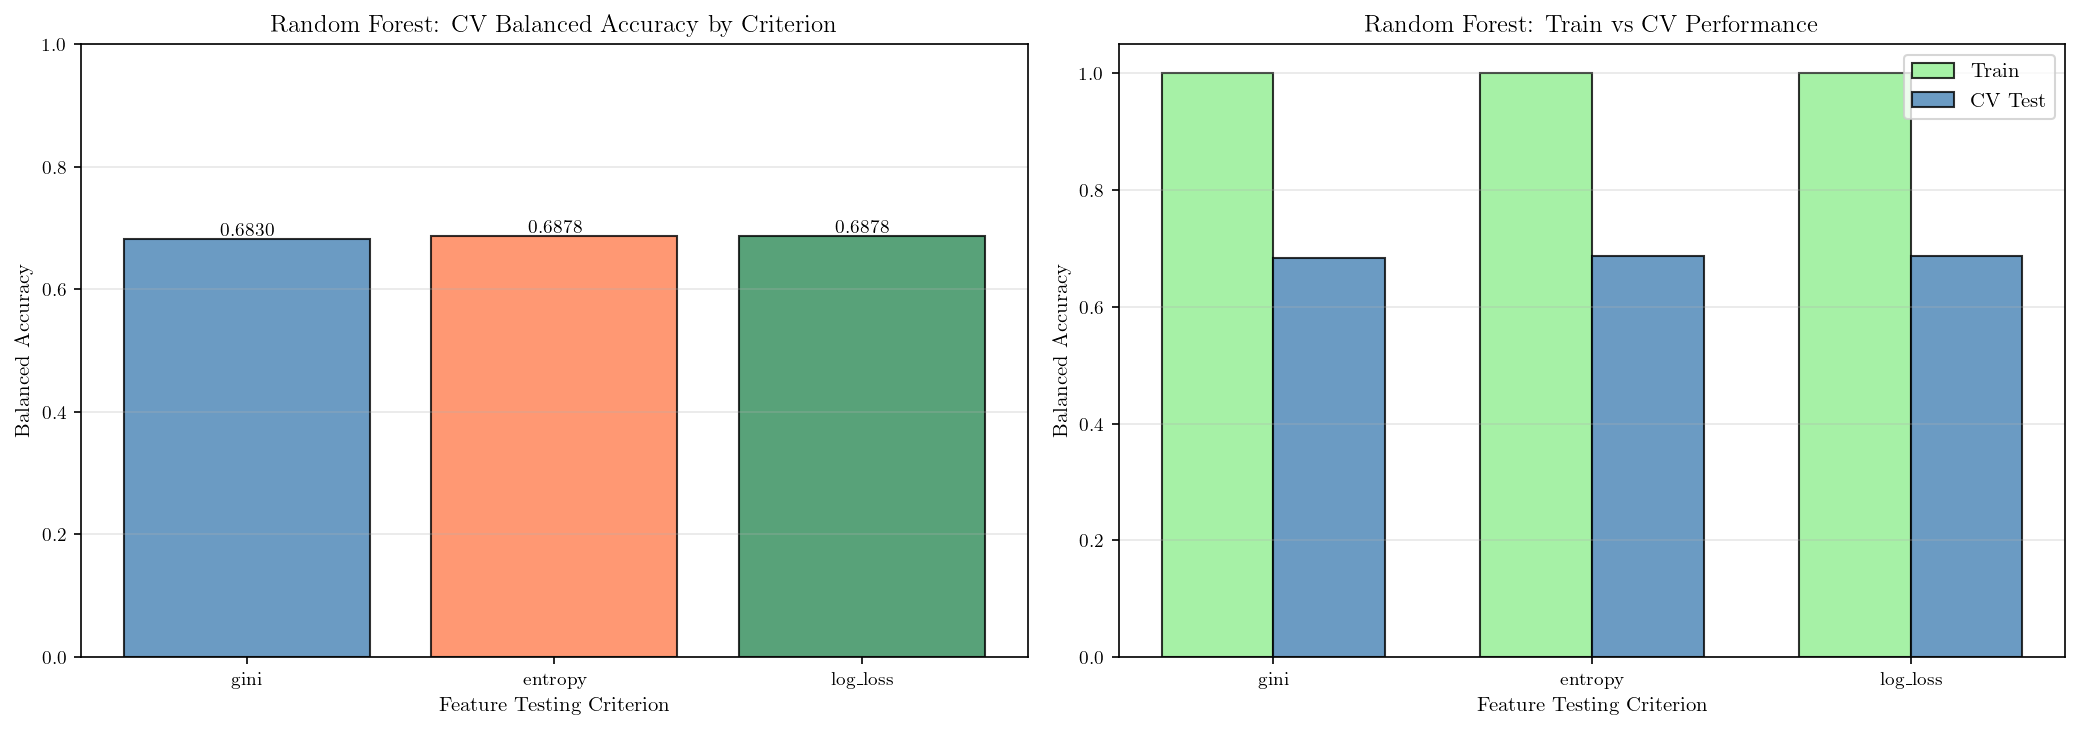

In [53]:
# Plot CV performance
criteria = list(cv_results["param_criterion"])
mean_test_scores = cv_results["mean_test_score"]
std_test_scores = cv_results["std_test_score"]
mean_train_scores = cv_results["mean_train_score"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of CV scores
x_pos = np.arange(len(criteria))
colors = ["steelblue", "coral", "seagreen"]
bars = axes[0].bar(x_pos, mean_test_scores, 
                   color=colors, alpha=0.8, edgecolor="black",
                   capsize=5)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(criteria)
axes[0].set_xlabel("Feature Testing Criterion")
axes[0].set_ylabel("Balanced Accuracy")
axes[0].set_title("Random Forest: CV Balanced Accuracy by Criterion")
axes[0].set_ylim([0, 1.0])
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, mean_test_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                 f"{val:.4f}", ha="center", fontsize=9)

# Right: Train vs CV comparison
width = 0.35
axes[1].bar(x_pos - width / 2, mean_train_scores, width,
            label="Train", color="lightgreen",
            edgecolor="black", alpha=0.8)
axes[1].bar(x_pos + width / 2, mean_test_scores, width,
            label="CV Test", color="steelblue",
            edgecolor="black", alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(criteria)
axes[1].set_xlabel("Feature Testing Criterion")
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_title("Random Forest: Train vs CV Performance")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
os.makedirs("q3", exist_ok=True)
plt.savefig("q3/q3_rf_criterion_tuning.pdf")
plt.show()

In [54]:
# Retrain on full training set with best criterion
rf_final = RandomForestClassifier(
    n_estimators=100, criterion=best_rf_criterion, random_state=42)
rf_final.fit(X_train, y_train)

# Evaluate on test set
y_pred = rf_final.predict(X_test)
metrics_rf = calc_metrics(y_test, y_pred)
print_metrics(metrics_rf, "Random Forest - Test Set Performance:")

performance_results["Random Forest"] = metrics_rf


Random Forest - Test Set Performance:
  Accuracy            : 0.6468
  Sensitivity         : 0.7835
  Specificity         : 0.5734
  Precision           : 0.4967
  Recall              : 0.7835
  Balanced Accuracy   : 0.6785


COMPARISON: Decision Tree vs Random Forest

Decision Tree:
  Accuracy            : 0.5856
  Sensitivity         : 0.6134
  Specificity         : 0.5706
  Precision           : 0.4343
  Recall              : 0.6134
  Balanced Accuracy   : 0.5920

Random Forest:
  Accuracy            : 0.6468
  Sensitivity         : 0.7835
  Specificity         : 0.5734
  Precision           : 0.4967
  Recall              : 0.7835
  Balanced Accuracy   : 0.6785


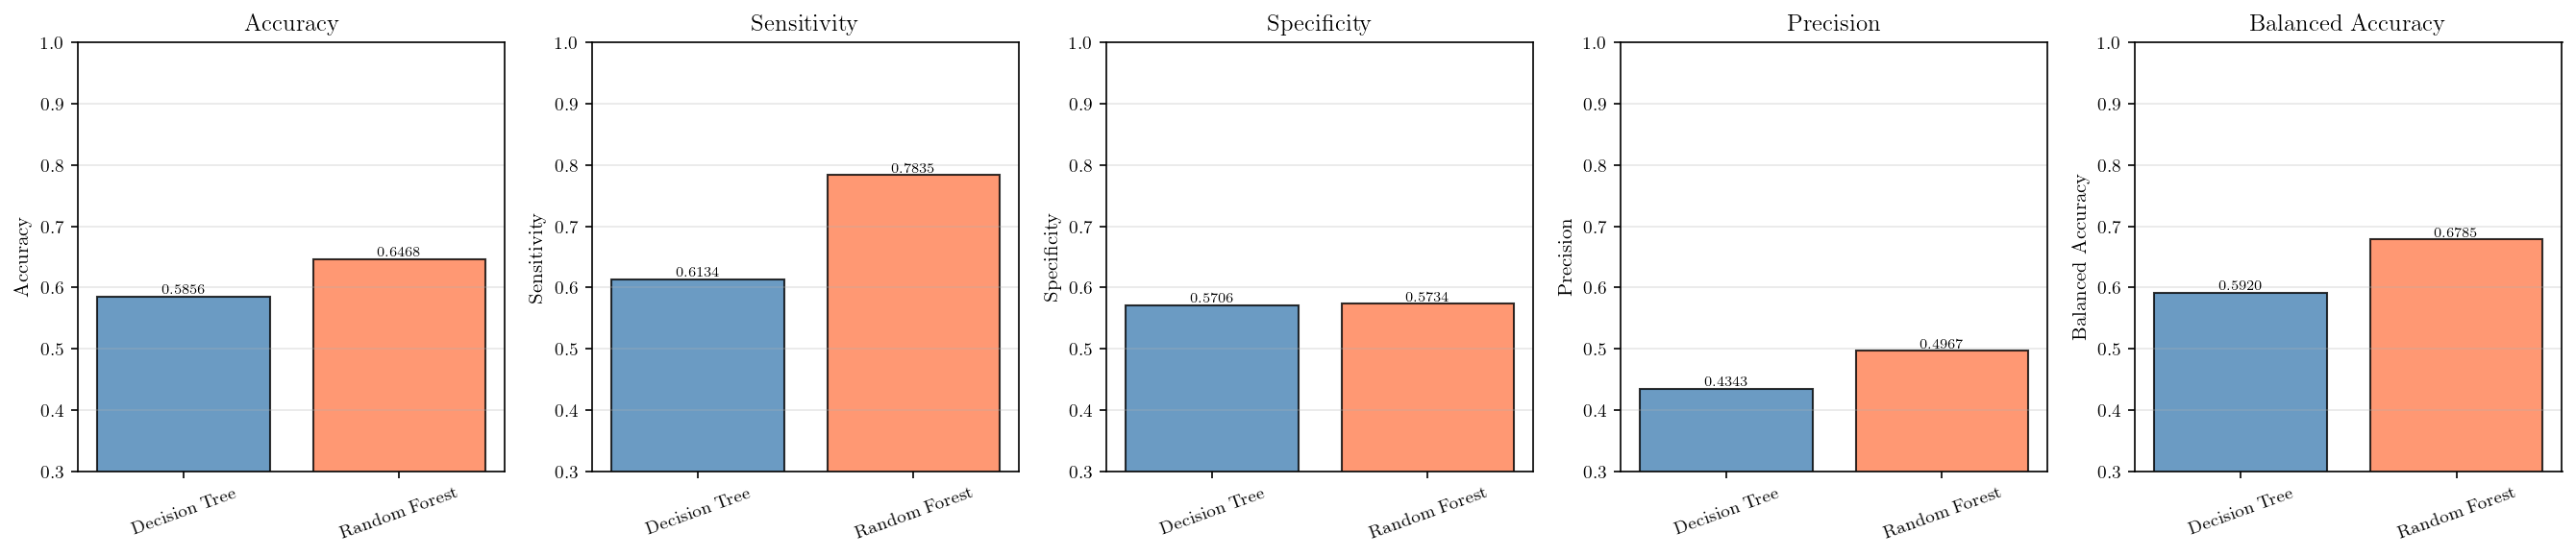

In [55]:
# Compare Decision Tree vs Random Forest
print(f"{'='*70}")
print("COMPARISON: Decision Tree vs Random Forest")
print(f"{'='*70}")
for name in ["Decision Tree", "Random Forest"]:
    print(f"\n{name}:")
    for k, v in performance_results[name].items():
        print(f"  {k:20s}: {v:.4f}")

# Summary comparison bar chart
model_names = ["Decision Tree", "Random Forest"]
metric_names = ["Accuracy", "Sensitivity", "Specificity",
                "Precision", "Balanced Accuracy"]
colors = ["steelblue", "coral"]

fig, axes = plt.subplots(1, len(metric_names), figsize=(18, 4))

for idx, metric in enumerate(metric_names):
    vals = [performance_results[m][metric] for m in model_names]
    bars = axes[idx].bar(model_names, vals, color=colors, alpha=0.8,
                         edgecolor="black")
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(metric)
    axes[idx].set_ylim([min(0.3, min(vals) - 0.05), 1.0])
    axes[idx].grid(axis="y", alpha=0.3)
    axes[idx].tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                       f"{val:.4f}", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("q3/q3_comparison_dt_vs_rf.pdf")
plt.show()

## Question 4 &mdash; Best Tree-Based Classifier

In [56]:
def predictMCIconverters(Xtest, data_dir):
    """Returns a vector of predictions with elements "0" for sMCI and "1"
    for pMCI, corresponding to each of the N_test features vectors in Xtest

    Xtest       N_test x 14 matrix of test feature vectors
    data_dir    full path to the folder containing the following files:
                train.fdg_pet.sMCI.csv, train.fdg_pet.pMCI.csv,
                test.fdg_pet.sMCI.csv, test.fdg_pet.pMCI.csv
    """
    train_sMCI = pd.read_csv(os.path.join(
        data_dir, "train.fdg_pet.sMCI.csv"), header=None)
    train_pMCI = pd.read_csv(os.path.join(
        data_dir, "train.fdg_pet.pMCI.csv"), header=None)
    test_sMCI = pd.read_csv(os.path.join(
        data_dir, "test.fdg_pet.sMCI.csv"), header=None)
    test_pMCI = pd.read_csv(os.path.join(
        data_dir, "test.fdg_pet.pMCI.csv"), header=None)

    # Use all available data for training
    X_all = pd.concat([train_sMCI, train_pMCI, test_sMCI,
                       test_pMCI], ignore_index=True)
    y_all = np.array(
        [0]*len(train_sMCI) + [1]*len(train_pMCI) +
        [0]*len(test_sMCI) + [1]*len(test_pMCI)
    )

    # Random Forest with tuned hyperparameters
    model = RandomForestClassifier(
        n_estimators=500,
        criterion="entropy",
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_all, y_all)
    ytest = model.predict(Xtest)

    return ytest

In [57]:
print("=" * 70)
print("QUESTION 4: Best Tree-Based Classifier (Random Forest)")
print("=" * 70)

# Tune Random Forest with broader grid search
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_q4 = RandomForestClassifier(
    criterion="entropy",
    random_state=42,
    n_jobs=-1,
)

grid_search = GridSearchCV(
    rf_q4,
    param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

print("\nRunning grid search for Random Forest hyperparameters...")
print(f"  n_estimators: {param_grid['n_estimators']}")
print(f"  max_depth: {param_grid['max_depth']}")
print(f"  min_samples_split: {param_grid['min_samples_split']}")
print(f"  min_samples_leaf: {param_grid['min_samples_leaf']}")
print(f"  max_features: {param_grid['max_features']}")
print("  Cross-validation: 5-fold stratified")

grid_search.fit(X_train, y_train)

best_rf_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print(f"\nBest parameters: {best_rf_params}")
print(f"Best CV Balanced Accuracy: {best_cv_score:.4f}")

QUESTION 4: Best Tree-Based Classifier (Random Forest)

Running grid search for Random Forest hyperparameters...
  n_estimators: [100, 200, 300, 500]
  max_depth: [None, 5, 10, 15, 20]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 5]
  max_features: ['sqrt', 'log2']
  Cross-validation: 5-fold stratified
Fitting 5 folds for each of 360 candidates, totalling 1800 fits

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Balanced Accuracy: 0.6955


In [60]:
# Evaluate best model on test set
y_pred = grid_search.best_estimator_.predict(X_test)
metrics_rf_q4 = calc_metrics(y_test, y_pred)
print_metrics(metrics_rf_q4, "Random Forest (Tuned) - Test Set Performance:")

performance_results["Random Forest (Tuned)"] = metrics_rf_q4

# Compare all models
print(f"\n{'='*70}")
print("COMPARISON: All Models")
print(f"{'='*70}")
for name in performance_results:
    print(f"\n{name}:")
    for k, v in performance_results[name].items():
        print(f"  {k:20s}: {v:.4f}")


Random Forest (Tuned) - Test Set Performance:
  Accuracy            : 0.6342
  Sensitivity         : 0.8144
  Specificity         : 0.5374
  Precision           : 0.4862
  Recall              : 0.8144
  Balanced Accuracy   : 0.6759

COMPARISON: All Models

Decision Tree:
  Accuracy            : 0.5856
  Sensitivity         : 0.6134
  Specificity         : 0.5706
  Precision           : 0.4343
  Recall              : 0.6134
  Balanced Accuracy   : 0.5920

Random Forest:
  Accuracy            : 0.6468
  Sensitivity         : 0.7835
  Specificity         : 0.5734
  Precision           : 0.4967
  Recall              : 0.7835
  Balanced Accuracy   : 0.6785

Random Forest (Tuned):
  Accuracy            : 0.6342
  Sensitivity         : 0.8144
  Specificity         : 0.5374
  Precision           : 0.4862
  Recall              : 0.8144
  Balanced Accuracy   : 0.6759


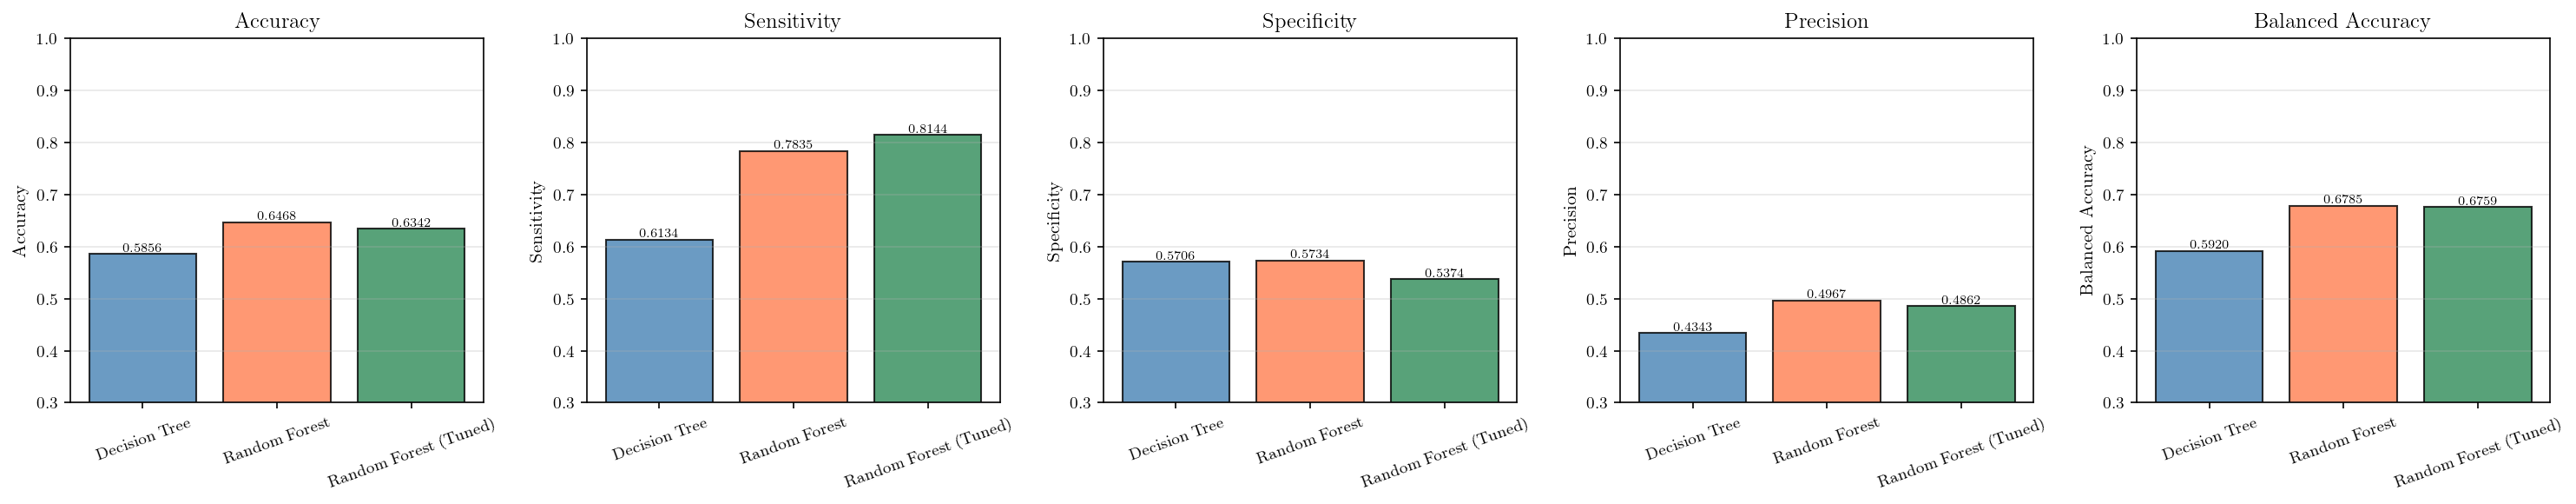

In [61]:
# Summary comparison bar chart
model_names = list(performance_results.keys())
metric_names = ["Accuracy", "Sensitivity", "Specificity",
                "Precision", "Balanced Accuracy"]
colors = ["steelblue", "coral", "seagreen"]

fig, axes = plt.subplots(1, len(metric_names), figsize=(20, 4))

for idx, metric in enumerate(metric_names):
    vals = [performance_results[m][metric] for m in model_names]
    bars = axes[idx].bar(model_names, vals, color=colors[:len(model_names)],
                         alpha=0.8, edgecolor="black")
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(metric)
    axes[idx].set_ylim([min(0.3, min(vals) - 0.05), 1.0])
    axes[idx].grid(axis="y", alpha=0.3)
    axes[idx].tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                       f"{val:.4f}", ha="center", fontsize=7)

plt.tight_layout()
os.makedirs("q4", exist_ok=True)
plt.savefig("q4/q4_comparison_all_models.pdf")
plt.show()

Random Forest (Tuned) Feature Importances (sorted):
   1. ctx-lh-middletemporal         : 0.1073
   2. ctx-lh-isthmuscingulate       : 0.0953
   3. ctx-rh-inferiortemporal       : 0.0819
   4. ctx-rh-middletemporal         : 0.0792
   5. ctx-lh-inferiortemporal       : 0.0768
   6. ctx-rh-precuneus              : 0.0767
   7. ctx-lh-inferiorparietal       : 0.0759
   8. ctx-lh-posteriorcingulate     : 0.0737
   9. ctx-rh-inferiorparietal       : 0.0642
  10. ctx-rh-isthmuscingulate       : 0.0641
  11. ctx-rh-posteriorcingulate     : 0.0609
  12. ctx-lh-supramarginal          : 0.0516
  13. ctx-lh-entorhinal             : 0.0484
  14. ctx-lh-precuneus              : 0.0441


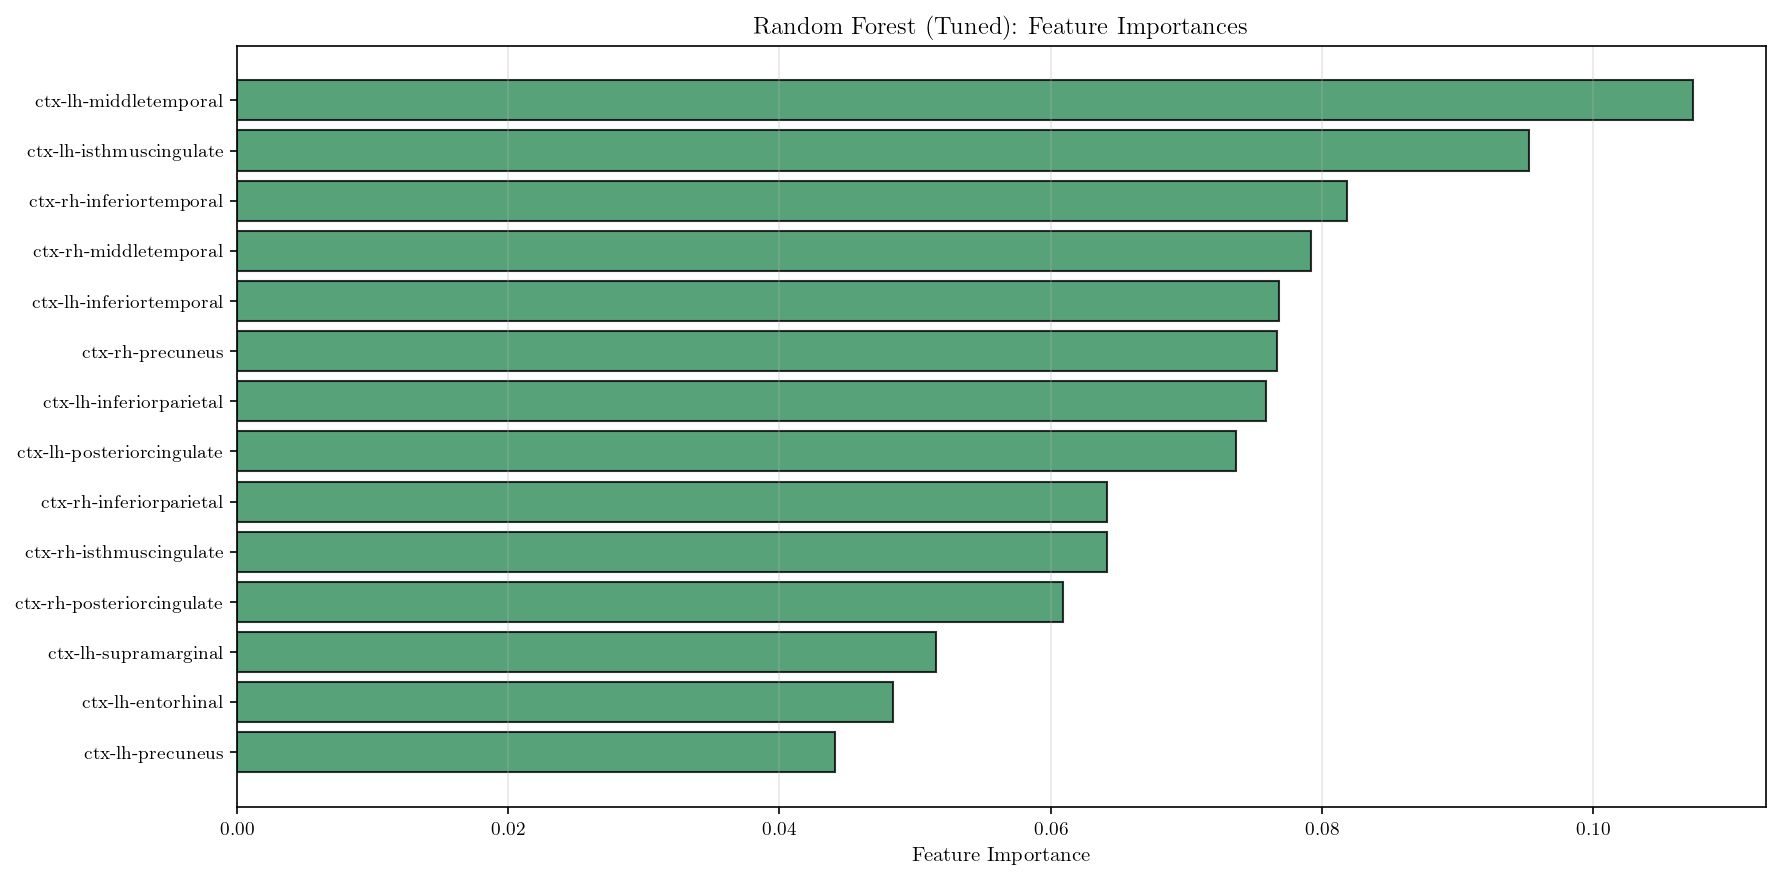

In [62]:
# Feature importance from tuned Random Forest
rf_q4_final = grid_search.best_estimator_
importances = rf_q4_final.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("Random Forest (Tuned) Feature Importances (sorted):")
for rank, idx in enumerate(sorted_idx, 1):
    print(f"  {rank:2d}. {FEATURE_NAMES[idx]:30s}: {importances[idx]:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.barh(range(len(FEATURE_NAMES)),
        importances[sorted_idx[::-1]],
        color="seagreen", edgecolor="black", alpha=0.8)
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_yticklabels([FEATURE_NAMES[i] for i in sorted_idx[::-1]])
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest (Tuned): Feature Importances")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("q4/q4_rf_feature_importances.pdf")
plt.show()